# Sistema de Triagem Preditiva - Risco Cardiovascular

Este projeto visa construir um sistema de triagem preditiva de risco cardiovascular usando dados clínicos e de estilo de vida. O objetivo principal é apoiar a decisão médica, priorizando a identificação de pacientes em risco crítico.
    
**Nota de Negócio:** Devido ao impacto clínico de um Falso Negativo (deixar um paciente em risco voltar para casa), este pipeline priorizará a métrica de **Recall** sobre a acurácia geral."

## Importar as bibliotecas necessárias

In [609]:
# Manipulação e Estrutura de Dados
import pandas as pd

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Divisão
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelos
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Métricas de Avaliação
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score


## Importar a base de dados

In [610]:
df = pd.read_csv("heart_attack_prediction_dataset.csv")

# Visualizar as primeiras linhas
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


## Analisando a base de dados

In [611]:
df.shape

(8763, 26)

In [612]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   str    
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   str    
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   str    
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                           

As colunas 'Patient ID', 'Country', 'Continent' e 'Hemisphere' foram removidas por não representarem características clínicas dos pacientes e, portanto, não contribuírem para a previsão do risco de ataque cardíaco.

In [613]:
# remove colunas desnecessárias
df = df.drop(columns=["Patient ID", "Country", "Continent", "Hemisphere"])

In [614]:
# remove dados duplicados
df.drop_duplicates(inplace=True)

In [615]:
# verificando valores nulos
df.isnull().sum()

Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Heart Attack Risk                  0
dtype: int64

In [616]:
df.dtypes

Age                                  int64
Sex                                    str
Cholesterol                          int64
Blood Pressure                         str
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                   str
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Heart Attack Risk                    int64
dtype: object

Os campos 'Sex', Blood Pressure' e 'Diet' são do tipo 'str' e devem ser tratados para valores numéricos.

In [617]:
# Verifica os valores possiveis para a coluna 'Sex'
df['Sex'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [618]:
# Verifica os valores possiveis para a coluna 'Blood Pressure'
df['Blood Pressure'].unique()

<StringArray>
[ '158/88',  '165/93',  '174/99', '163/100',   '91/88',  '172/86',  '102/73',
  '131/68', '144/105',  '160/70',
 ...
  '135/96',  '112/62', '120/108',  '108/84',  '129/61',  '174/63',  '102/92',
  '137/94',   '94/76',  '119/67']
Length: 3915, dtype: str

In [619]:
# Verifica os valores possiveis para a coluna 'Diet'
df['Diet'].unique()

<StringArray>
['Average', 'Unhealthy', 'Healthy']
Length: 3, dtype: str

Nessa análise alguns pontos importantes foram levantados:
- 'Sex' pode ser transformado para 0 e 1 pois só tem 2 valores possíveis.
- 'Blood Pressure' não pode ser transformado da forma em que está, ex: 135/96. A solução seria quebrar em 2 colunas.
- 'Diet' possui 3 valores ['Average', 'Unhealthy', 'Healthy']. Solução será criar 2 colunas com binárias. Sendo que:
    - 'Average': 0 nas duas colunas.
    - 'Unhealthy': 1 na coluna 'Diet_Unhealthy'
    - 'Healthy': 1 na coluna 'Diet_Healthy'

In [620]:
labelEncoder = LabelEncoder()

# transforma valores 0 e 1
df['Sex'] = labelEncoder.fit_transform(df['Sex'])

# transforma coluna 'Blood Pressure'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])
df.drop(columns=['Blood Pressure'], inplace=True)

# transforma coluna 'Diet'
df = pd.get_dummies(df, columns=['Diet'], drop_first=True, dtype=int)

df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic_BP,Diastolic_BP,Diet_Healthy,Diet_Unhealthy
0,67,1,208,72,0,0,1,0,0,4.168189,...,261404,31.251233,286,0,6,0,158,88,0,0
1,21,1,389,98,1,1,1,1,1,1.813242,...,285768,27.194973,235,1,7,0,165,93,0,1
2,21,0,324,72,1,0,0,0,0,2.078353,...,235282,28.176571,587,4,4,0,174,99,1,0
3,84,1,383,73,1,1,1,0,1,9.828130,...,125640,36.464704,378,3,4,0,163,100,0,0
4,66,1,318,93,1,1,1,1,0,5.804299,...,160555,21.809144,231,1,5,0,91,88,0,1


In [621]:
df.dtypes

Age                                  int64
Sex                                  int64
Cholesterol                          int64
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Heart Attack Risk                    int64
Systolic_BP                          int64
Diastolic_BP                         int64
Diet_Healthy                         int64
Diet_Unheal

## Análise exploratória


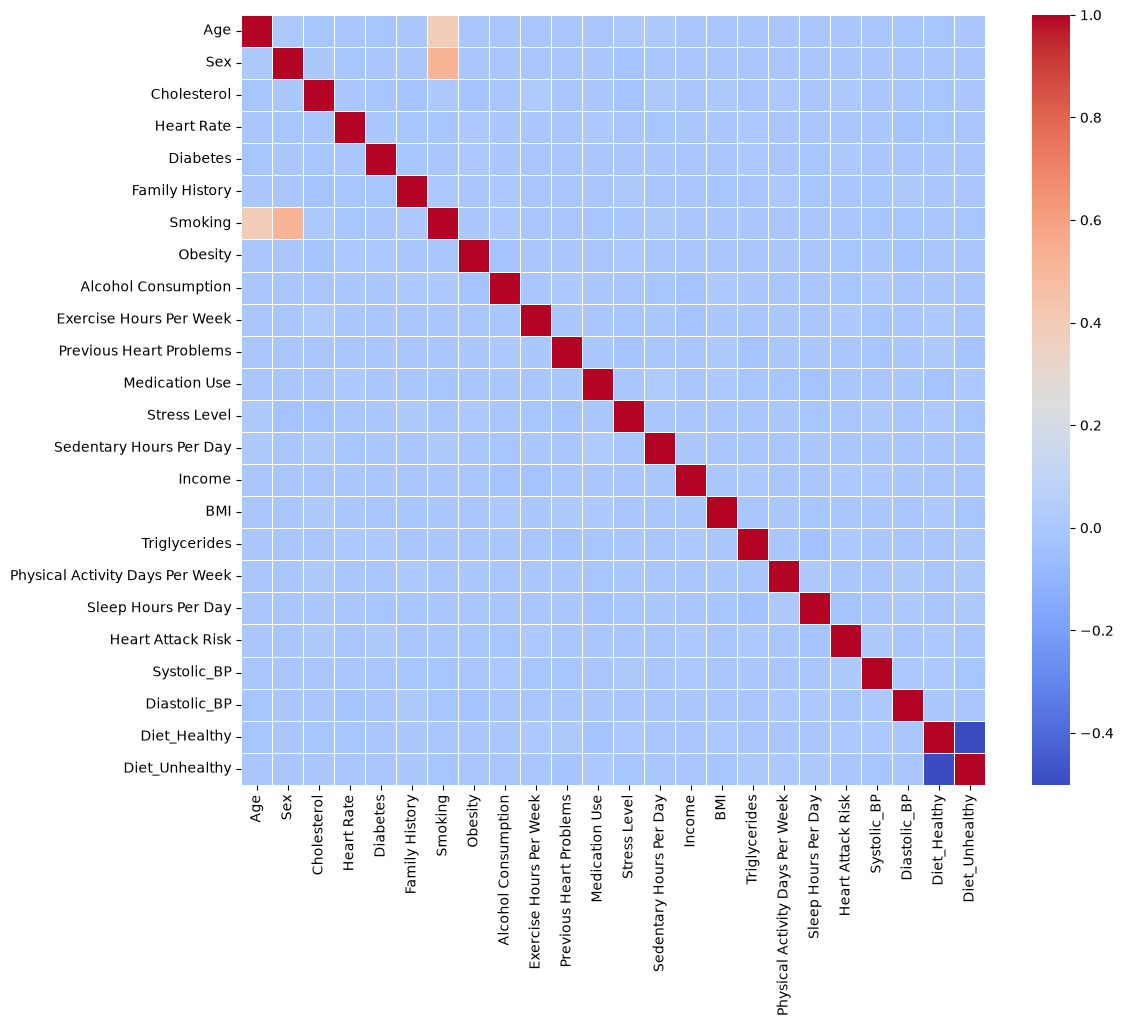

In [622]:
# mapa de correlação entre as colunas
correlation = df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(correlation, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5)
plt.show()

Nesse primeiro gráfico de correlação não ficou claro a relação entre a coluna target e as demais.

In [623]:
# mostrar correlação em valores númericos.
corr = (
    df.corr(numeric_only=True)["Heart Attack Risk"]
      .sort_values()
)

corr

Sleep Hours Per Day               -0.018528
Alcohol Consumption               -0.013778
Obesity                           -0.013318
Diastolic_BP                      -0.007509
Sedentary Hours Per Day           -0.005613
Physical Activity Days Per Week   -0.005014
Heart Rate                        -0.004251
Stress Level                      -0.004111
Smoking                           -0.004051
Family History                    -0.001652
Diet_Unhealthy                    -0.000803
BMI                                0.000020
Previous Heart Problems            0.000274
Medication Use                     0.002234
Sex                                0.003095
Age                                0.006403
Diet_Healthy                       0.009409
Income                             0.009628
Triglycerides                      0.010471
Exercise Hours Per Week            0.011133
Diabetes                           0.017225
Systolic_BP                        0.018585
Cholesterol                     

A correlação ficou entre -0.02 e 0.02.

Isso indica ausência de forte relação linear entre cada variável individualmente e o target. Entretanto, modelos de Machine Learning podem aprender relações mais complexas entre múltiplas variáveis.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Triglycerides'}>,
        <Axes: title={'center': 'Heart Rate'}>,
        <Axes: title={'center': 'Systolic_BP'}>],
       [<Axes: title={'center': 'Diastolic_BP'}>, <Axes: >, <Axes: >]],
      dtype=object)

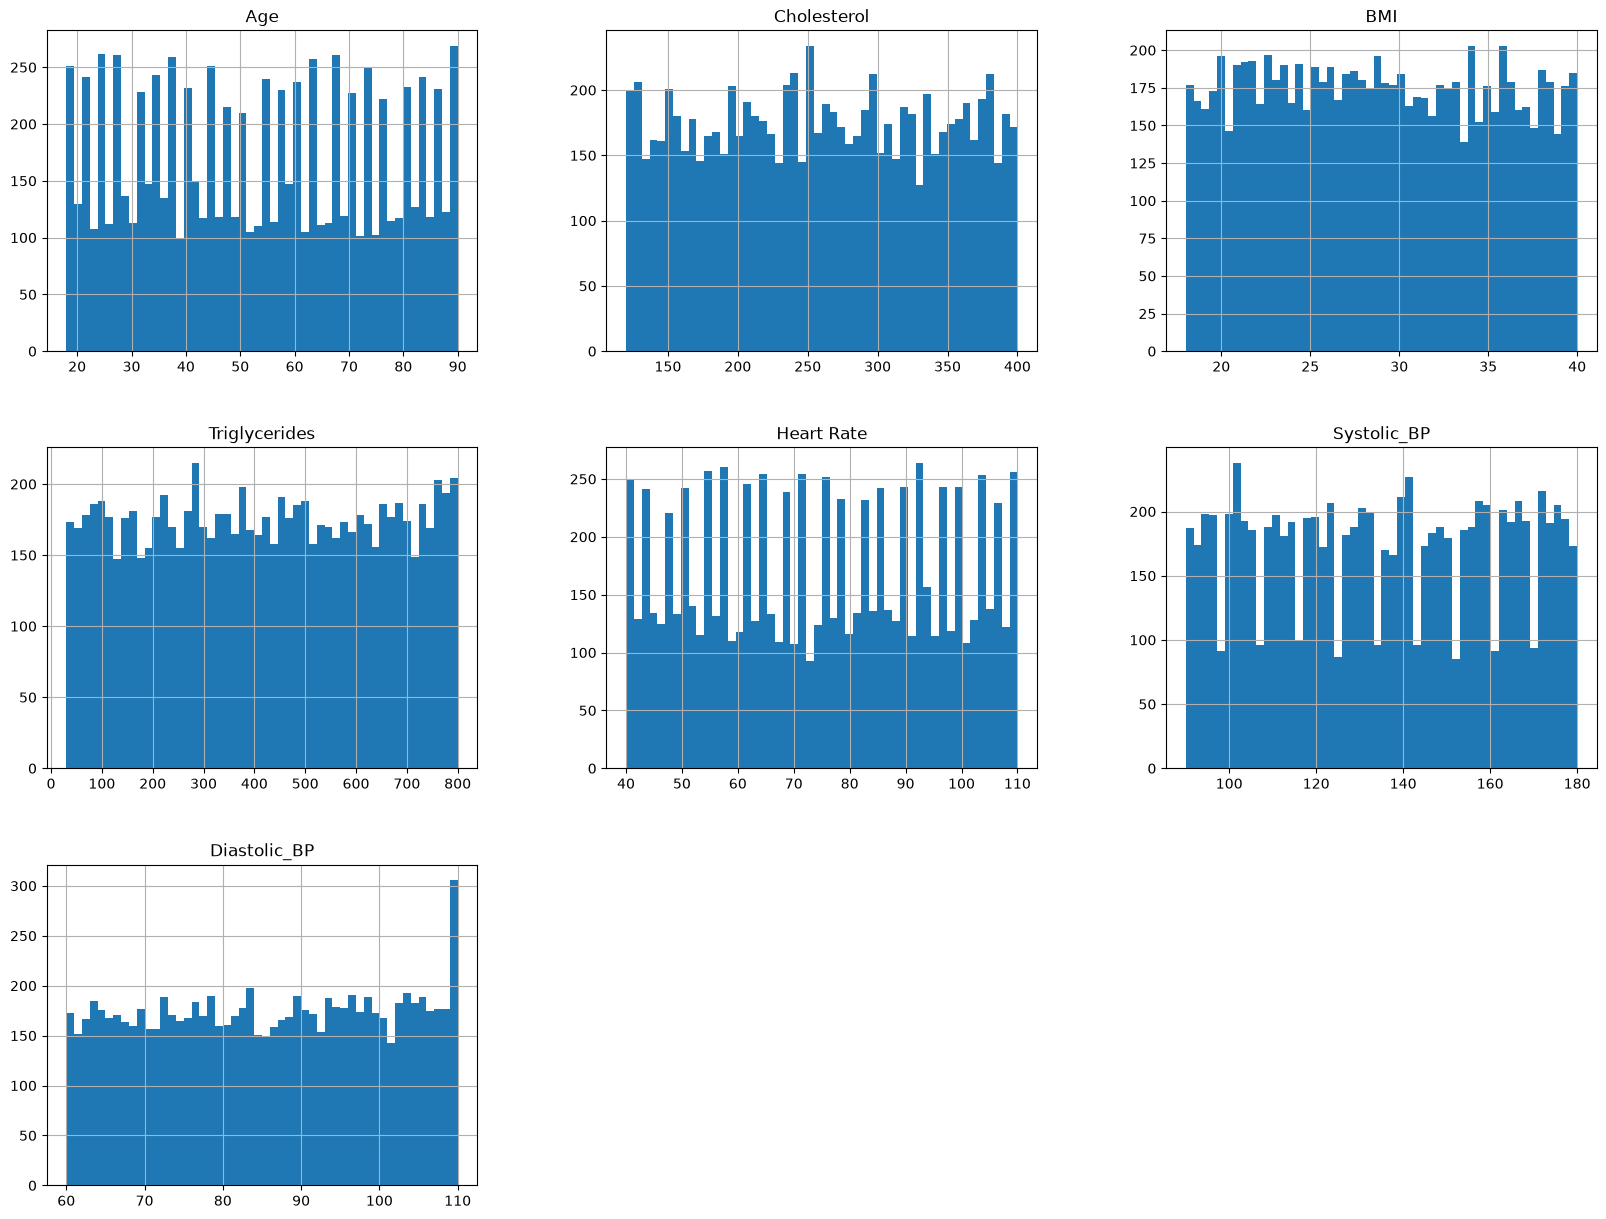

In [624]:
colunas = [
    'Age',
    'Cholesterol',
    'BMI',
    'Triglycerides',
    'Heart Rate',
    'Systolic_BP',
    'Diastolic_BP'
]
df[colunas].hist(bins=50, figsize=(20, 15))

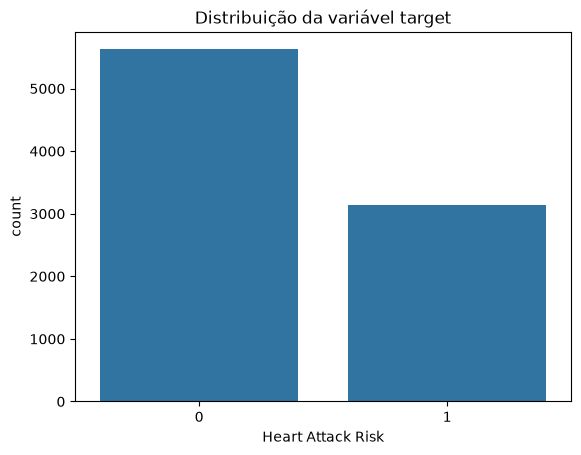

Heart Attack Risk
0    64.18
1    35.82
Name: proportion, dtype: float64

In [625]:
sns.countplot(x="Heart Attack Risk", data=df)

plt.title("Distribuição da variável target")
plt.show()

(df["Heart Attack Risk"].value_counts(normalize=True) * 100).round(2)

A variável target apresenta uma distribuição moderadamente desbalanceada, com aproximadamente 64% dos registros classificados como 'Sem Risco' e 36% como 'Em Risco'. Para preservar essa proporção durante a separação dos dados, foi utilizada a opção 'stratify' no 'train_test_split'.

## Divisão entre treino e teste

In [626]:
X = df.drop("Heart Attack Risk", axis=1)
y = df["Heart Attack Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [627]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Treinamento de modelos

In [628]:
classifiers = [
    ('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Support Vector Machine', SVC(class_weight='balanced', random_state=42)),    
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]

results = []

for model_name, model in classifiers:

    # Treinar modelo
    model.fit(X_train_scaled, y_train)

    # Fazer previsões
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Modelo': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Recall',
    ascending=False
)

results_df

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.498003,0.348921,0.463376,0.398085
4,Support Vector Machine,0.495151,0.338770,0.429936,0.378947
1,Decision Tree,0.545921,0.352632,0.320064,0.335559
3,K-Nearest Neighbors,0.573873,0.369231,0.267516,0.310249
2,Random Forest,0.610953,0.402878,0.178344,0.247241
5,Gradient Boosting,0.633771,0.281250,0.014331,0.027273


## Modelo selecionado

Com base no melhor F1-Score e Recall, a Regressão Logística foi escolhida para uma análise mais detalhada.

              precision    recall  f1-score   support

           0       0.63      0.52      0.57      1125
           1       0.35      0.46      0.40       628

    accuracy                           0.50      1753
   macro avg       0.49      0.49      0.48      1753
weighted avg       0.53      0.50      0.51      1753



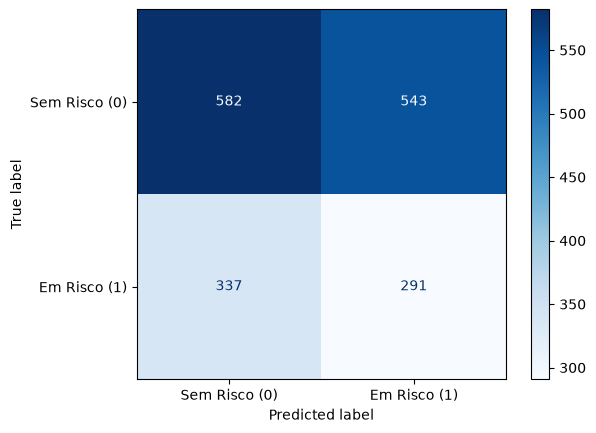

In [629]:
final_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Sem Risco (0)', 'Em Risco (1)'],
    cmap='Blues'
)

plt.show()

# Conclusão

Neste trabalho foram comparados diferentes algoritmos de classificação para prever o risco de ataque cardíaco.

Considerando que, em aplicações médicas, deixar de identificar um paciente em risco pode ter consequências graves, o Recall foi definido como principal métrica de avaliação.

Entre os modelos testados, a Regressão Logística apresentou o melhor desempenho para esse critério, sendo escolhida como modelo final.

Os resultados mostram que, embora as variáveis apresentem baixa correlação linear individual com a variável alvo, a combinação delas permitiu ao modelo identificar padrões relevantes para a classificação.